파라미터만 바꿔서 수정해봄
| 번호    | 수정 항목       | 변경 내용                      | 목적 / 기대 효과                              |
| ----- | ----------- | -------------------------- | --------------------------------------- |
| **①** | Focal Loss  | `alpha=1.0`, `gamma=0.5`   | 과도한 억제 완화 → **불량(소수 클래스) Recall↑, F1↑** |
| **②** | 임계값 탐색 범위   | `0.20~0.80`, step `0.02`   | 더 넓은 threshold 탐색으로 **F1 최적화**          |
| **③** | FedProx μ   | `mu=0.005`                 | 과한 제약 완화로 **학습 안정성↑, 수렴 개선**            |
| **④** | αᵢ 가중치      | `beta=1.0`                 | 클래스 다양성(cᵢ) 반영 강화 → **불균형 완화**          |
| **⑤** | 로컬 학습       | `epochs=7`, `lr=0.0005`    | 소수 클래스 학습량↑, 과적합 방지                     |
| **⑥** | Fine-tuning | `ft_epochs=5`, `lr=0.0005` | 개인화 성능 향상 및 F1 세부 개선                    |


[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5038 → 0.5928 | ΔW=1.3264

=== Round 2 ===
[Round 2] Global Accuracy: 0.5928 → 0.5905 | ΔW=0.0845

=== Round 3 ===
[Round 3] Global Accuracy: 0.5905 → 0.6060 | ΔW=0.0694

=== Round 4 ===
[Round 4] Global Accuracy: 0.6060 → 0.6207 | ΔW=0.0661

=== Round 5 ===
[Round 5] Global Accuracy: 0.6207 → 0.6252 | ΔW=0.0660

=== Round 6 ===
[Round 6] Global Accuracy: 0.6252 → 0.6248 | ΔW=0.0708

=== Round 7 ===
[Round 7] Global Accuracy: 0.6248 → 0.6350 | ΔW=0.0576

=== Round 8 ===
[Round 8] Global Accuracy: 0.6350 → 0.6297 | ΔW=0.0639

=== Round 9 ===
[Round 9] Global Accuracy: 0.6297 → 0.6354 | ΔW=0.0543

=== Round 10 ===
[Round 10] Global Accuracy: 

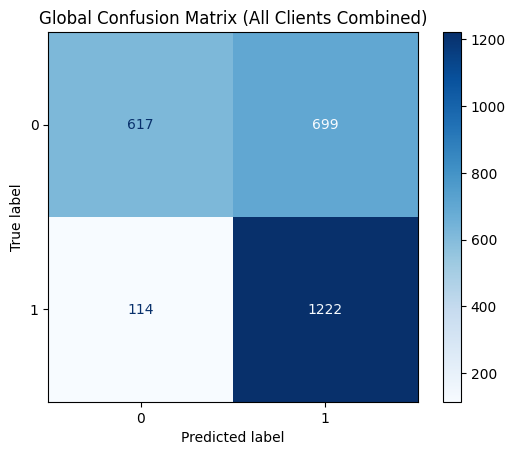


Final Global Accuracy (thr=0.36): 0.6934

[Global Classification Report]
              precision    recall  f1-score   support

           0     0.8440    0.4688    0.6028      1316
           1     0.6361    0.9147    0.7504      1336

    accuracy                         0.6934      2652
   macro avg     0.7401    0.6918    0.6766      2652
weighted avg     0.7393    0.6934    0.6772      2652


 Per-Client Fine-tuning (Personalization)

--- Client A Fine-tuning ---
[Client A] Fine-tuned Accuracy: 0.7087
[Client {cid}] Fine-tuned Classification Report:
              precision    recall  f1-score   support

           0     0.9014    0.4682    0.6163       566
           1     0.6412    0.9489    0.7653       567

    accuracy                         0.7087      1133
   macro avg     0.7713    0.7085    0.6908      1133
weighted avg     0.7712    0.7087    0.6909      1133


--- Client B Fine-tuning ---
[Client B] Fine-tuned Accuracy: 0.7632
[Client {cid}] Fine-tuned Classification R

In [26]:
# ============================================================
# Federated Learning (TabNet) + αᵢ Mitigation
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation + Fine-tuning
# ============================================================
# FedProx + FedBN + Fine-tuning 적용 버전
import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']


# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    # 결함 라벨 없으면 0으로 채우기
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 여러 결함 라벨 → 이진 라벨
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처 생성
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')    # 결측 포함 행 제거
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res


def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 공통 피처만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)

        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test],
                              generator=torch.Generator().manual_seed(42))

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)


# ------------------------------------------------
# 2) TabNet 구조 정의 (Simple 버전)
# ------------------------------------------------
def sparsemax(logits, dim=-1):
    z = logits
    z_sorted, _ = torch.sort(z, dim=dim, descending=True)
    dim_size = z.size(dim)
    range_vals = torch.arange(
        1, dim_size + 1,
        device=z.device,
        dtype=z.dtype
    ).view(*([1] * (z.dim() - 1)), dim_size)
    zs_cumsum = torch.cumsum(z_sorted, dim=dim)
    k = (1 + range_vals * z_sorted > zs_cumsum).type(z.dtype)
    k_max = torch.max(range_vals * k, dim=dim, keepdim=True)[0]
    zs_cumsum_k = torch.gather(zs_cumsum, dim, (k_max.long() - 1))
    tau = (zs_cumsum_k - 1) / k_max
    output = torch.clamp(z - tau, min=0)
    return output


class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2)

    def forward(self, x):
        x = self.fc(x)
        x = self.bn(x)
        out, gate = x.chunk(2, dim=-1)
        return out * torch.sigmoid(gate)


class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, n_d, n_a, n_shared=1, n_independent=1):
        super().__init__()
        self.n_d, self.n_a = n_d, n_a
        self.shared = nn.ModuleList()
        for i in range(n_shared):
            in_dim = input_dim if i == 0 else n_d + n_a
            self.shared.append(GLUBlock(in_dim, n_d + n_a))
        self.indep = nn.ModuleList()
        for _ in range(n_independent):
            self.indep.append(GLUBlock(n_d + n_a, n_d + n_a))

    def forward(self, x):
        out = x
        for block in self.shared:
            out = block(out)
        for block in self.indep:
            out = block(out)
        return out


class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, feature_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)

    def forward(self, x, prior):
        x = self.fc(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = x * prior
        mask = sparsemax(x, dim=-1)
        return mask


class SimpleTabNet(nn.Module):
    def __init__(self,
                 input_dim,
                 num_classes=2,
                 n_d=16,
                 n_a=16,
                 n_steps=3,
                 gamma=1.3):
        super().__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.n_d, self.n_a = n_d, n_a
        self.n_steps, self.gamma = n_steps, gamma

        self.decision_layers = nn.ModuleList(
            [FeatureTransformer(input_dim, n_d, n_a) for _ in range(n_steps)]
        )
        self.att = AttentiveTransformer(n_d, input_dim)
        self.fc_out = nn.Linear(n_d, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        prior = torch.ones(batch_size, self.input_dim, device=x.device)
        aggregated = torch.zeros(batch_size, self.n_d, device=x.device)

        x_flat = x
        decision = None

        for step in range(self.n_steps):
            if step == 0:
                mask = sparsemax(x_flat, dim=-1)
            else:
                mask = self.att(decision, prior)

            masked_x = x_flat * mask
            h = self.decision_layers[step](masked_x)
            d, a = h[:, :self.n_d], h[:, self.n_d:]

            decision = d
            aggregated = aggregated + decision
            prior = prior * (self.gamma - mask)

        logits = self.fc_out(aggregated)
        return logits


# ------------------------------------------------
# 3) Focal Loss (불균형 완화)
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=0.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# ------------------------------------------------
# 4) αᵢ 구성요소 (nᵢ, cᵢ) + FedBN 스타일 Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = 0.0
    for c in class_counts.values():
        if c > 0:
            p = c / total
            H -= p * math.log(p)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K
    ci = max(1e-8, frac_k * (H_tilde / logK))
    return ci


def aggregate_with_softmax_weights(state_dicts,
                                   alpha_components,
                                   rho=1.0,
                                   beta=0.7,
                                   theta=0.5,
                                   use_fedbn=True):
    """
    FedBN 스타일:
      - BatchNorm 관련 파라미터(running_mean, running_var, num_batches_tracked, 'bn' 포함)는 평균 안 내고
        기준 클라이언트(A 등)의 것을 그대로 사용
      - 나머지 파라미터는 αᵢ 가중 softmax 평균
    """
    if not state_dicts:
        return None

    client_ids = list(state_dicts.keys())

    # αᵢ 계산
    logits = {}
    for cid, comp in alpha_components.items():
        log_weight = (
            math.log(comp["n_i"] ** rho + 1e-12) +
            math.log(comp["c_i"] ** beta + 1e-12) +
            math.log(comp["t_i"] ** theta + 1e-12)
        )
        logits[cid] = log_weight

    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = state_dicts[client_ids[0]]
    global_sd = {}

    for k in base_sd.keys():
        # FedBN: BN 관련 파라미터는 평균 내지 않고 기준 클라이언트 것 사용
        if use_fedbn and (
            "bn" in k or
            "running_mean" in k or
            "running_var" in k or
            "num_batches_tracked" in k
        ):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = None
            for cid, sd in state_dicts.items():
                w = alphas[cid]
                t = sd[k] * w
                if agg is None:
                    agg = t.clone()
                else:
                    agg += t
            global_sd[k] = agg

    return global_sd


# ------------------------------------------------
# 5) Local Train (FedProx 지원) + Evaluate + Threshold Search
# ------------------------------------------------
def local_train(base_model,
                dataset,
                lr,
                epochs,
                device,
                global_params=None,
                mu=0.0):
    """
    base_model: 서버에서 받은 글로벌 모델
    global_params: FedProx용 글로벌 파라미터 리스트 (None이면 Prox 적용 안함)
    mu: FedProx 계수 (0이면 일반 로컬 학습)
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    if global_params is not None and mu > 0.0:
        global_params = [p.detach().clone().to(device) for p in global_params]
    else:
        global_params = None

    crit = FocalLoss(alpha=2.0, gamma=2.0)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx 항 추가
            if global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    acc = (y_true_np == y_pred_np).mean()

    if return_preds:
        return acc, y_true, y_pred
    return acc


def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.2, 0.81, 0.02)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, y_true, y_pred = evaluate(model, dataset, device,
                                     threshold=t,
                                     return_preds=True)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t


# ------------------------------------------------
# 6) 메인 루프 + Fine-tuning
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    parser.add_argument("--mu", type=float, default=0.005, help="FedProx mu")
    parser.add_argument("--ft_epochs", type=int, default=5, help="Fine-tuning epochs per client")
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = SimpleTabNet(input_dim=input_dim, num_classes=2).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    participation_log = {cid: 0 for cid in clients}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
    prev_global = copy.deepcopy(global_model.state_dict())

    round_log = {"round": [], "acc": [], "dW": []}

    # ===================== Federated Rounds =====================
    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        # 라운드별 참여 클라이언트 선택
        selected = [cid for cid in clients
                    if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        for cid in selected:
            participation_log[cid] += 1

        state_dicts, alpha_components = {}, {}

        before_acc = evaluate(global_model, combined_test, device)

        # FedProx용 글로벌 파라미터 백업
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 로컬 학습
        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()

            state_dict = local_train(
                base_model=global_model,
                dataset=ds,
                lr=0.0005,
                epochs=7,
                device=device,
                global_params=None,
                mu=0.0
            )
            state_dicts[cid] = state_dict

            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        # FedBN 스타일 Aggregation
        new_global = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=1.0,
            beta=1.0,
            theta=0.5,
            use_fedbn=True
        )
        if new_global is None:
            continue

        global_model.load_state_dict(new_global)

        after_acc, y_true, y_pred = evaluate(
            global_model, combined_test, device,
            return_preds=True
        )

        # ΔW 계산 (non-BN 파라미터 기준)
        dWs = []
        for k in global_model.state_dict().keys():
            if global_model.state_dict()[k].dtype in (torch.float32, torch.float64):
                diff = global_model.state_dict()[k] - prev_global[k]
                dWs.append(torch.norm(diff).item())
        dW = float(np.mean(dWs)) if len(dWs) > 0 else 0.0
        prev_global = copy.deepcopy(global_model.state_dict())

        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f} | ΔW={dW:.4f}")
        round_log["round"].append(rnd)
        round_log["acc"].append(after_acc)
        round_log["dW"].append(dW)

    # ===================== Global Evaluation =====================
    print("\n===============================")
    print(" Global Model Evaluation (All Clients Combined)")
    print("===============================")

    best_t = find_best_threshold(global_model, combined_test, device)

    global_acc, global_y_true, global_y_pred = evaluate(
        global_model, combined_test, device,
        return_preds=True, threshold=best_t
    )

    cm = confusion_matrix(global_y_true, global_y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Global Confusion Matrix (All Clients Combined)")
    plt.show()

    print(f"\nFinal Global Accuracy (thr={best_t:.2f}): {global_acc:.4f}")
    print("\n[Global Classification Report]")
    print(classification_report(global_y_true, global_y_pred, digits=4))

    # ===================== Per-Client Fine-tuning =====================
    print("\n===============================")
    print(" Per-Client Fine-tuning (Personalization)")
    print("===============================")

    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")

        # 글로벌 모델을 초기값으로 사용, FedProx 없이 로컬 추가 학습
        ft_state = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.001,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,
            mu=0.0
        )

        local_model = copy.deepcopy(global_model).to(device)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(
            local_model,
            data["test"],
            device,
            threshold=best_t,
            return_preds=True
        )

        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print("[Client {cid}] Fine-tuned Classification Report:")
        print(classification_report(yt_c, yp_c, digits=4))

[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5038 → 0.5811 | ΔW=1.9166

=== Round 2 ===
[Round 2] Global Accuracy: 0.5811 → 0.5694 | ΔW=0.1692

=== Round 3 ===
[Round 3] Global Accuracy: 0.5694 → 0.5758 | ΔW=0.1736

=== Round 4 ===
[Round 4] Global Accuracy: 0.5758 → 0.5848 | ΔW=0.1703

=== Round 5 ===
[Round 5] Global Accuracy: 0.5848 → 0.6003 | ΔW=0.1933

=== Round 6 ===
[Round 6] Global Accuracy: 0.6003 → 0.6082 | ΔW=0.2049

=== Round 7 ===
[Round 7] Global Accuracy: 0.6082 → 0.6210 | ΔW=0.1446

=== Round 8 ===
[Round 8] Global Accuracy: 0.6210 → 0.5924 | ΔW=0.2068

=== Round 9 ===
[Round 9] Global Accuracy: 0.5924 → 0.6127 | ΔW=0.1845

=== Round 10 ===
[Round 10] Global Accuracy: 

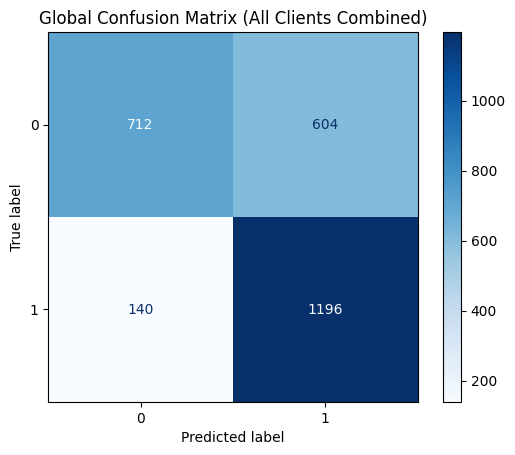


Final Global Accuracy (thr=0.46): 0.7195

[Global Classification Report]
              precision    recall  f1-score   support

           0     0.8357    0.5410    0.6568      1316
           1     0.6644    0.8952    0.7628      1336

    accuracy                         0.7195      2652
   macro avg     0.7501    0.7181    0.7098      2652
weighted avg     0.7494    0.7195    0.7102      2652


 Per-Client Fine-tuning (Personalization)

--- Client A Fine-tuning ---
[Client A] Fine-tuned Accuracy: 0.7202
[Client {cid}] Fine-tuned Classification Report:
              precision    recall  f1-score   support

           0     0.8000    0.5866    0.6769       566
           1     0.6741    0.8536    0.7533       567

    accuracy                         0.7202      1133
   macro avg     0.7370    0.7201    0.7151      1133
weighted avg     0.7370    0.7202    0.7151      1133


--- Client B Fine-tuning ---
[Client B] Fine-tuned Accuracy: 0.7737
[Client {cid}] Fine-tuned Classification R

In [27]:
# ============================================================
# Federated Learning (TabNet) + αᵢ Mitigation
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation + Fine-tuning
# ============================================================
# FedProx + FedBN + Fine-tuning 적용 버전
import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']


# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    # 결함 라벨 없으면 0으로 채우기
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 여러 결함 라벨 → 이진 라벨
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처 생성
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')    # 결측 포함 행 제거
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res


def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 공통 피처만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)

        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test],
                              generator=torch.Generator().manual_seed(42))

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)


# ------------------------------------------------
# 2) TabNet 구조 정의 (Simple 버전)
# ------------------------------------------------
def sparsemax(logits, dim=-1):
    z = logits
    z_sorted, _ = torch.sort(z, dim=dim, descending=True)
    dim_size = z.size(dim)
    range_vals = torch.arange(
        1, dim_size + 1,
        device=z.device,
        dtype=z.dtype
    ).view(*([1] * (z.dim() - 1)), dim_size)
    zs_cumsum = torch.cumsum(z_sorted, dim=dim)
    k = (1 + range_vals * z_sorted > zs_cumsum).type(z.dtype)
    k_max = torch.max(range_vals * k, dim=dim, keepdim=True)[0]
    zs_cumsum_k = torch.gather(zs_cumsum, dim, (k_max.long() - 1))
    tau = (zs_cumsum_k - 1) / k_max
    output = torch.clamp(z - tau, min=0)
    return output


class GLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.bn = nn.BatchNorm1d(out_dim * 2)

    def forward(self, x):
        x = self.fc(x)
        x = self.bn(x)
        out, gate = x.chunk(2, dim=-1)
        return out * torch.sigmoid(gate)


class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, n_d, n_a, n_shared=1, n_independent=1):
        super().__init__()
        self.n_d, self.n_a = n_d, n_a
        self.shared = nn.ModuleList()
        for i in range(n_shared):
            in_dim = input_dim if i == 0 else n_d + n_a
            self.shared.append(GLUBlock(in_dim, n_d + n_a))
        self.indep = nn.ModuleList()
        for _ in range(n_independent):
            self.indep.append(GLUBlock(n_d + n_a, n_d + n_a))

    def forward(self, x):
        out = x
        for block in self.shared:
            out = block(out)
        for block in self.indep:
            out = block(out)
        return out


class AttentiveTransformer(nn.Module):
    def __init__(self, in_dim, feature_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, feature_dim)
        self.bn = nn.BatchNorm1d(feature_dim)

    def forward(self, x, prior):
        x = self.fc(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = x * prior
        mask = sparsemax(x, dim=-1)
        return mask


class SimpleTabNet(nn.Module):
    def __init__(self,
                 input_dim,
                 num_classes=2,
                 n_d=16,
                 n_a=16,
                 n_steps=3,
                 gamma=1.3):
        super().__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.n_d, self.n_a = n_d, n_a
        self.n_steps, self.gamma = n_steps, gamma

        self.decision_layers = nn.ModuleList(
            [FeatureTransformer(input_dim, n_d, n_a) for _ in range(n_steps)]
        )
        self.att = AttentiveTransformer(n_d, input_dim)
        self.fc_out = nn.Linear(n_d, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        prior = torch.ones(batch_size, self.input_dim, device=x.device)
        aggregated = torch.zeros(batch_size, self.n_d, device=x.device)

        x_flat = x
        decision = None

        for step in range(self.n_steps):
            if step == 0:
                mask = sparsemax(x_flat, dim=-1)
            else:
                mask = self.att(decision, prior)

            masked_x = x_flat * mask
            h = self.decision_layers[step](masked_x)
            d, a = h[:, :self.n_d], h[:, self.n_d:]

            decision = d
            aggregated = aggregated + decision
            prior = prior * (self.gamma - mask)

        logits = self.fc_out(aggregated)
        return logits


# ------------------------------------------------
# 3) Focal Loss (불균형 완화)
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.2, gamma=0.3):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# ------------------------------------------------
# 4) αᵢ 구성요소 (nᵢ, cᵢ) + FedBN 스타일 Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = 0.0
    for c in class_counts.values():
        if c > 0:
            p = c / total
            H -= p * math.log(p)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K
    ci = max(1e-8, frac_k * (H_tilde / logK))
    return ci


def aggregate_with_softmax_weights(state_dicts,
                                   alpha_components,
                                   rho=1.0,
                                   beta=0.7,
                                   theta=0.5,
                                   use_fedbn=True):
    """
    FedBN 스타일:
      - BatchNorm 관련 파라미터(running_mean, running_var, num_batches_tracked, 'bn' 포함)는 평균 안 내고
        기준 클라이언트(A 등)의 것을 그대로 사용
      - 나머지 파라미터는 αᵢ 가중 softmax 평균
    """
    if not state_dicts:
        return None

    client_ids = list(state_dicts.keys())

    # αᵢ 계산
    logits = {}
    for cid, comp in alpha_components.items():
        log_weight = (
            math.log(comp["n_i"] ** rho + 1e-12) +
            math.log(comp["c_i"] ** beta + 1e-12) +
            math.log(comp["t_i"] ** theta + 1e-12)
        )
        logits[cid] = log_weight

    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = state_dicts[client_ids[0]]
    global_sd = {}

    for k in base_sd.keys():
        # FedBN: BN 관련 파라미터는 평균 내지 않고 기준 클라이언트 것 사용
        if use_fedbn and (
            "bn" in k or
            "running_mean" in k or
            "running_var" in k or
            "num_batches_tracked" in k
        ):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = None
            for cid, sd in state_dicts.items():
                w = alphas[cid]
                t = sd[k] * w
                if agg is None:
                    agg = t.clone()
                else:
                    agg += t
            global_sd[k] = agg

    return global_sd


# ------------------------------------------------
# 5) Local Train (FedProx 지원) + Evaluate + Threshold Search
# ------------------------------------------------
def local_train(base_model,
                dataset,
                lr,
                epochs,
                device,
                global_params=None,
                mu=0.0):
    """
    base_model: 서버에서 받은 글로벌 모델
    global_params: FedProx용 글로벌 파라미터 리스트 (None이면 Prox 적용 안함)
    mu: FedProx 계수 (0이면 일반 로컬 학습)
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    if global_params is not None and mu > 0.0:
        global_params = [p.detach().clone().to(device) for p in global_params]
    else:
        global_params = None

    crit = FocalLoss(alpha=2.0, gamma=2.0)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx 항 추가
            if global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    acc = (y_true_np == y_pred_np).mean()

    if return_preds:
        return acc, y_true, y_pred
    return acc


def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.2, 0.81, 0.01)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, y_true, y_pred = evaluate(model, dataset, device,
                                     threshold=t,
                                     return_preds=True)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t


# ------------------------------------------------
# 6) 메인 루프 + Fine-tuning
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    parser.add_argument("--mu", type=float, default=0.003, help="FedProx mu")
    parser.add_argument("--ft_epochs", type=int, default=6, help="Fine-tuning epochs per client")
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = SimpleTabNet(input_dim=input_dim, num_classes=2,
    n_d=32, n_a=32, n_steps=5,   # ← 용량/스텝 ↑
    gamma=1.5 ).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    participation_log = {cid: 0 for cid in clients}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])
    prev_global = copy.deepcopy(global_model.state_dict())

    round_log = {"round": [], "acc": [], "dW": []}

    # ===================== Federated Rounds =====================
    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        # 라운드별 참여 클라이언트 선택
        selected = [cid for cid in clients
                    if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        for cid in selected:
            participation_log[cid] += 1

        state_dicts, alpha_components = {}, {}

        before_acc = evaluate(global_model, combined_test, device)

        # FedProx용 글로벌 파라미터 백업
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 로컬 학습
        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()

            state_dict = local_train(
                base_model=global_model,
                dataset=ds,
                lr=0.0005,
                epochs=7,
                device=device,
                global_params=None,
                mu=0.0
            )
            state_dicts[cid] = state_dict

            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        # FedBN 스타일 Aggregation
        new_global = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=1.0,
            beta=1.0,
            theta=0.5,
            use_fedbn=True
        )
        if new_global is None:
            continue

        global_model.load_state_dict(new_global)

        after_acc, y_true, y_pred = evaluate(
            global_model, combined_test, device,
            return_preds=True
        )

        # ΔW 계산 (non-BN 파라미터 기준)
        dWs = []
        for k in global_model.state_dict().keys():
            if global_model.state_dict()[k].dtype in (torch.float32, torch.float64):
                diff = global_model.state_dict()[k] - prev_global[k]
                dWs.append(torch.norm(diff).item())
        dW = float(np.mean(dWs)) if len(dWs) > 0 else 0.0
        prev_global = copy.deepcopy(global_model.state_dict())

        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f} | ΔW={dW:.4f}")
        round_log["round"].append(rnd)
        round_log["acc"].append(after_acc)
        round_log["dW"].append(dW)

    # ===================== Global Evaluation =====================
    print("\n===============================")
    print(" Global Model Evaluation (All Clients Combined)")
    print("===============================")

    best_t = find_best_threshold(global_model, combined_test, device)

    global_acc, global_y_true, global_y_pred = evaluate(
        global_model, combined_test, device,
        return_preds=True, threshold=best_t
    )

    cm = confusion_matrix(global_y_true, global_y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title("Global Confusion Matrix (All Clients Combined)")
    plt.show()

    print(f"\nFinal Global Accuracy (thr={best_t:.2f}): {global_acc:.4f}")
    print("\n[Global Classification Report]")
    print(classification_report(global_y_true, global_y_pred, digits=4))

    # ===================== Per-Client Fine-tuning =====================
    print("\n===============================")
    print(" Per-Client Fine-tuning (Personalization)")
    print("===============================")

    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")

        # 글로벌 모델을 초기값으로 사용, FedProx 없이 로컬 추가 학습
        ft_state = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.001,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,
            mu=0.0
        )

        local_model = copy.deepcopy(global_model).to(device)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(
            local_model,
            data["test"],
            device,
            threshold=best_t,
            return_preds=True
        )

        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print("[Client {cid}] Fine-tuned Classification Report:")
        print(classification_report(yt_c, yp_c, digits=4))